In [107]:
!pip install pyspark --quiet
print("PySpark installation complete!")

PySpark installation complete!


In [108]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import year, month, to_date, col, round as spark_round

import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

#Creating SparkSession
spark = SparkSession.builder \
        .appName('Day4_BigData_Sales')\
        .config('spark.sql.adaptive.enabled','true')\
        .getOrCreate()
print(f'Spark version : {spark.version}')
print(f'Spark App Name: {spark.sparkContext.appName}')
print(f'Spark Session : ACTIVE')

Spark version : 4.0.2
Spark App Name: Day4_BigData_Sales
Spark Session : ACTIVE


In [109]:
df_bronze = spark.read\
            .option('header','true')\
            .option('inferSchema','true')\
            .csv('/content/drive/MyDrive/Data_Engineering_Internship/large_sales_data.csv')
print("====BRONZE====")
print(f"Rows: {df_bronze.count()}")
print(f"Columns: {len(df_bronze.columns)}")
print()
df_bronze.printSchema()

====BRONZE====
Rows: 5000
Columns: 13

root
 |-- order_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)



In [110]:
print("First 5 rows-")
df_bronze.show(5,truncate=False)

print("\nBasic statistics for numeric columns:")
df_bronze.select('quantity','unit_price','revenue').describe().show()

First 5 rows-
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|order_id|customer_name|product   |category   |quantity|unit_price|revenue|order_date|city     |region|sales_rep  |payment_method  |order_status|
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|1001    |Sneha Reddy  |Monitor   |Electronics|12      |22000     |264000 |2023-05-21|Mumbai   |West  |Meera Patel|UPI             |Delivered   |
|1002    |Ramesh Kumar |Printer   |Electronics|10      |12000     |120000 |2023-08-05|Delhi    |North |Anil Sharma|Credit Card     |Shipped     |
|1003    |Rahul Mishra |Mouse     |Accessories|10      |800       |8000   |2023-01-14|Ahmedabad|West  |Meera Patel|Cash on Delivery|Shipped     |
|1004    |Suresh Rao   |Tablet    |Electronics|5       |32000     |160000 |2023-01-04|Surat    |West  |Ravi Ku

In [111]:
df_bronze.write \
          .mode('overwrite') \
          .parquet('/content/drive/MyDrive/Data_Engineering_Internship/bronze_sales_data')

import os
def get_dir_size(path):
  if os.path.isfile(path):
    return os.path.getsize(path) /1024
  total = 0
  for dirpath, dirnames, filenames in os.walk(path):
    for f in filenames:
      total += os.path.getsize(os.path.join(dirpath, f)) /1024
  return total

csv_size = get_dir_size('/content/drive/MyDrive/Data_Engineering_Internship/large_sales_data.csv')
parquet_size = get_dir_size('/content/drive/MyDrive/Data_Engineering_Internship/bronze_sales_data')
reduction = (1 - parquet_size/csv_size) * 100

print(f"CSV file size: {csv_size:.2f} KB")
print(f"Parquet file size: {parquet_size:.2f} KB")
print(f"Reduction in size: {reduction:.2f}%")

CSV file size: 529.31 KB
Parquet file size: 55.10 KB
Reduction in size: 89.59%


In [112]:
#====SILVER====
df_silver = df_bronze \
            .dropDuplicates() \
            .dropna(subset=['order_id','product','revenue'])

df_silver = df_silver.withColumn(
    'order_date',
    to_date(col('order_date'),'yyyy-MM-dd')
)

df_silver = df_silver \
            .withColumn('order_year',year(col('order_date'))) \
            .withColumn('order_month',month(col('order_date')))

df_silver = df_silver.withColumn(
    'revenue_category',
    F.when(col('revenue')>40000,'High')
     .when(col('revenue')>10000,'Medium')
     .otherwise('Low')
)

print(f"Silver layer rows : {df_silver.count()}")
df_silver.select('product','revenue','order_month','order_year','revenue_category').show(5,truncate=False)

Silver layer rows : 5000
+--------+-------+-----------+----------+----------------+
|product |revenue|order_month|order_year|revenue_category|
+--------+-------+-----------+----------+----------------+
|Keyboard|13200  |2          |2023      |Medium          |
|Webcam  |17500  |1          |2023      |Medium          |
|Speaker |58500  |4          |2023      |High            |
|Keyboard|9600   |12         |2023      |Low             |
|Laptop  |180000 |8          |2023      |High            |
+--------+-------+-----------+----------+----------------+
only showing top 5 rows


In [113]:
df_silver.write \
      .mode('overwrite') \
      .parquet('/content/drive/MyDrive/Data_Engineering_Internship/silver_sales_data')

print(f'Silver Size : {get_dir_size("/content/drive/MyDrive/Data_Engineering_Internship/silver_sales_data"):.2f}KB')

df_verify = spark.read.parquet('/content/drive/MyDrive/Data_Engineering_Internship/silver_sales_data')
print(f"Read - back rows: {df_verify.count()}(Should match silver count)")
df_verify.printSchema()


Silver Size : 59.81KB
Read - back rows: 5000(Should match silver count)
root
 |-- order_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_year: integer (nullable = true)
 |-- order_month: integer (nullable = true)
 |-- revenue_category: string (nullable = true)



In [114]:
top_products = df_silver \
            .groupBy('product') \
            .agg(
                F.sum('revenue').alias('total_revenue'),
                F.count('order_id').alias('order_count'),
                F.avg('revenue').alias('avg_revenue')
            ) \
            .orderBy('total_revenue', ascending=False) \
            .limit(5)
print('===TOP 5 PRODUCTS===')
top_products.show(truncate=False)
#

===TOP 5 PRODUCTS===
+-------+-------------+-----------+------------------+
|product|total_revenue|order_count|avg_revenue       |
+-------+-------------+-----------+------------------+
|Laptop |182700000    |502        |363944.22310756973|
|Tablet |135104000    |532        |253954.8872180451 |
|Monitor|82126000     |481        |170740.12474012474|
|Printer|44544000     |488        |91278.68852459016 |
|Speaker|16317000     |470        |34717.02127659575 |
+-------+-------------+-----------+------------------+



In [115]:
revenue_by_region = df_silver \
                    .groupBy('region') \
                    .agg(
                        F.sum("revenue").alias('Total_Revenue'),\
                        F.count("order_id").alias("Total_Orders"),\
                        F.countDistinct("customer_name").alias("Unique_Customers")
                    ) \
                    .orderBy('total_revenue', ascending=False)
revenue_by_region.show(truncate=False)

+------+-------------+------------+----------------+
|region|Total_Revenue|Total_Orders|Unique_Customers|
+------+-------------+------------+----------------+
|West  |198275600    |2021        |15              |
|South |147145900    |1483        |15              |
|North |99878400     |995         |15              |
|East  |50547700     |501         |15              |
+------+-------------+------------+----------------+



In [116]:
names_by_region = df_silver \
                  .groupBy('region') \
                  .agg(\
                      F.collect_set('customer_name').alias('Customer_Names')
                  )
names_by_region.show(truncate=False)

+------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|region|Customer_Names                                                                                                                                                                                     |
+------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|South |[Meera Joshi, Ananya Das, Kiran Kumar, Vikram Iyer, Pooja Gupta, Ramesh Kumar, Rahul Mishra, Divya Singh, Arjun Nair, Sneha Reddy, Priya Patel, Suresh Rao, Kavya Nambiar, Amit Verma, Tanvi Mehta]|
|East  |[Meera Joshi, Ananya Das, Kiran Kumar, Vikram Iyer, Pooja Gupta, Ramesh Kumar, Rahul Mishra, Divya Singh, Arjun Nair, Sneha Reddy, Priya Patel, Suresh Rao, Kavya Nambiar, A

In [117]:
monthly_trend = df_silver \
                .withColumn('month_name', F.date_format('order_date', 'MMMM')) \
                .groupBy('order_month', 'month_name') \
                .agg(
                    F.sum('revenue').alias('Monthly_revenue'),
                    F.count('order_id').alias('Monthly_orders')
                ) \
                .orderBy('order_month', ascending=True) \
                .select('month_name', 'Monthly_revenue', 'Monthly_orders')

monthly_trend.show()

+----------+---------------+--------------+
|month_name|Monthly_revenue|Monthly_orders|
+----------+---------------+--------------+
|   January|       41068200|           423|
|  February|       34485400|           375|
|     March|       40031200|           451|
|     April|       38857100|           390|
|       May|       39984500|           423|
|      June|       40707400|           390|
|      July|       42640700|           405|
|    August|       43718500|           418|
| September|       37640200|           398|
|   October|       47839000|           479|
|  November|       44577100|           419|
|  December|       44298300|           429|
+----------+---------------+--------------+



In [118]:
gold_region = revenue_by_region
gold_region.write.mode('overwrite').parquet('/content/drive/MyDrive/Data_Engineering_Internship/gold_region.parquet')
print('Gold Parquet 1 saved: sales_gold_region.praquet')

gold_product = df_silver \
               .groupBy('product', 'category') \
               .agg(\
                   F.sum('revenue').alias('total_revenue'),\
                   F.count('order_id').alias('order_count'),\
                   spark_round(F.avg('revenue'),2).alias('avg_revenue'),\
                   F.max('revenue').alias('largest_order')\
               ) \
               .orderBy('total_revenue', ascending = False)
gold_product.write.mode('overwrite').parquet('/content/drive/MyDrive/Data_Engineering_Internship/gold_product.parquet')
print('Gold Parquet 2 saved: sales_gold_product.praquet')

Gold Parquet 1 saved: sales_gold_region.praquet
Gold Parquet 2 saved: sales_gold_product.praquet


In [119]:
gold_monthly = monthly_trend
gold_monthly.write.mode('overwrite').parquet('/content/drive/MyDrive/Data_Engineering_Internship/gold_monthly.parquet')
print('Gold Parquet 3 saved: sales_gold_monthly.praquet')

Gold Parquet 3 saved: sales_gold_monthly.praquet


In [120]:
gold_monthly.show(8)

+----------+---------------+--------------+
|month_name|Monthly_revenue|Monthly_orders|
+----------+---------------+--------------+
|   January|       41068200|           423|
|  February|       34485400|           375|
|     March|       40031200|           451|
|     April|       38857100|           390|
|       May|       39984500|           423|
|      June|       40707400|           390|
|      July|       42640700|           405|
|    August|       43718500|           418|
+----------+---------------+--------------+
only showing top 8 rows


In [121]:
#Visualization
region_pd = spark.read.parquet('/content/drive/MyDrive/Data_Engineering_Internship/gold_region.parquet').toPandas()
product_pd = spark.read.parquet('/content/drive/MyDrive/Data_Engineering_Internship/gold_product.parquet').toPandas()
monthly_pd = spark.read.parquet('/content/drive/MyDrive/Data_Engineering_Internship/gold_monthly.parquet').toPandas()

print('Gold Tables converted to Pandas')
print(f'Region Pandas: {region_pd.shape}')
print(f'Product Pandas: {product_pd.shape}')
print(f'Monthly Pandas: {monthly_pd.shape}')

region_pd = region_pd.sort_values('Total_Revenue',ascending=False)
product_pd = product_pd.sort_values('total_revenue',ascending=False)
monthly_pd = monthly_pd.sort_values('month_name',ascending=True)

Gold Tables converted to Pandas
Region Pandas: (4, 4)
Product Pandas: (10, 6)
Monthly Pandas: (12, 3)


In [122]:
print(region_pd.head())
print('=============================================================')
print(product_pd.head())
print('=============================================================')
print(monthly_pd.head())

  region  Total_Revenue  Total_Orders  Unique_Customers
0   West      198275600          2021                15
1  South      147145900          1483                15
2  North       99878400           995                15
3   East       50547700           501                15
   product     category  total_revenue  order_count  avg_revenue  \
0   Laptop  Electronics      182700000          502    363944.22   
1   Tablet  Electronics      135104000          532    253954.89   
2  Monitor  Electronics       82126000          481    170740.12   
3  Printer  Electronics       44544000          488     91278.69   
4  Speaker  Electronics       16317000          470     34717.02   

   largest_order  
0         675000  
1         480000  
2         330000  
3         180000  
4          67500  
   month_name  Monthly_revenue  Monthly_orders
3       April         38857100             390
7      August         43718500             418
11   December         44298300             429
1    Febr

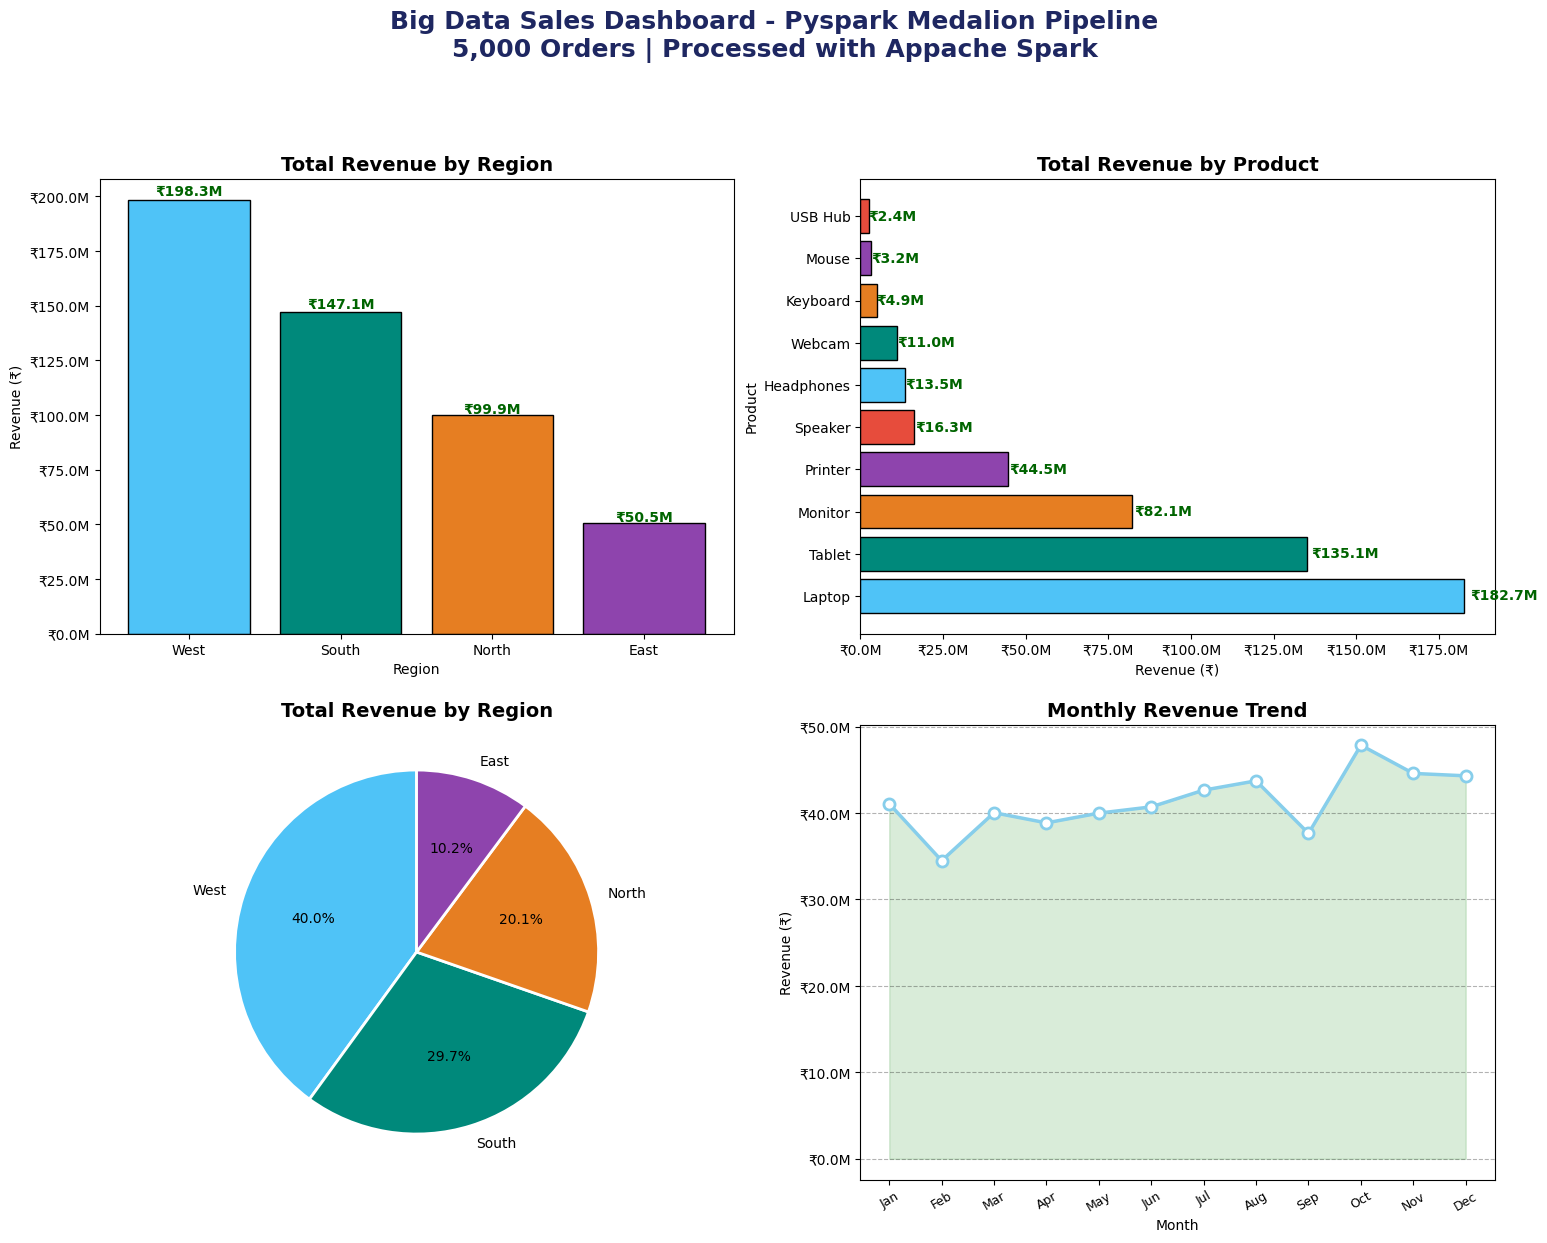

In [140]:
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle(
    'Big Data Sales Dashboard - Pyspark Medalion Pipeline\n'
    '5,000 Orders | Processed with Appache Spark',
    fontsize=18, fontweight='bold',color='#1E2761', y=1.01
)
colors4 = ['#4FC3F7','#00897B','#E67E22','#8E44AD','#E74C3C']

#pannel 1

ax1 = axes[0, 0]
bars1 = ax1.bar(region_pd['region'], region_pd['Total_Revenue'], color=colors4[:len(region_pd)],edgecolor='black')


for bar in bars1:
  ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
           f"₹{bar.get_height()/1e6 :.1f}M",
           ha='center', fontsize=10,fontweight='bold',color='Darkgreen')

ax1.set_title("Total Revenue by Region",fontsize=14,fontweight='bold')
ax1.set_ylabel('Revenue (₹)')
ax1.set_xlabel('Region')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"₹{x/1e6:.1f}M"))

#axes[0, 1].set_visible(False)
#axes[1, 0].set_visible(False)
#axes[1, 1].set_visible(False)

#pannel 2

ax2 = axes[0, 1]
bars2 = ax2.barh(product_pd['product'], product_pd['total_revenue'], color=colors4[:len(product_pd)],edgecolor='black')

for bar in bars2:
  ax2.text(bar.get_x() + bar.get_width()*1.01, bar.get_y() + bar.get_height()/2,
           f"₹{bar.get_width()/1e6 :.1f}M",
           va='center', fontsize=10,fontweight='bold',color='Darkgreen')

ax2.set_title("Total Revenue by Product",fontsize=14,fontweight='bold')
ax2.set_xlabel('Revenue (₹)')
ax2.set_ylabel('Product')
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"₹{x/1e6:.1f}M"))

#pannel 3 (pie chart)

ax3 = axes[1, 0]
ax3.pie(
    region_pd['Total_Revenue'],
    labels=region_pd['region'],
    colors=colors4[:len(region_pd)],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

ax3.set_title("Total Revenue by Region", fontsize=14, fontweight='bold')

"""ax4 = axes[1, 1]
rev_cat = df_silver.groupBy('revenue_category').count().orderBy('revenue_category').toPandas()
ax4.pie(rev_cat['count'],
        labels=rev_cat['revenue_category'],
        colors=['#4FC3F7','#00897B','#E67E22','#8E44AD','#E74C3C'],
        autopct='%1.1f%%',startangle=90,
        wedgeprops={'edgecolor':'white','linewidth':2})
ax4.set_title('Revenue Category Distribution',fontsize=14,fontweight='bold') """

ax4 = axes[1,1]
import datetime
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# Create a mapping from full month names to 0-indexed month numbers
month_name_to_num_0_indexed = {
    datetime.date(2000, m, 1).strftime('%B'): m - 1
    for m in range(1, 13)
}

monthly_pd['temp_month_num'] = monthly_pd['month_name'].map(month_name_to_num_0_indexed)

monthly_pd = monthly_pd.sort_values('temp_month_num', ascending=True).reset_index(drop=True)

monthly_labels = [month_names[idx] for idx in monthly_pd['temp_month_num']]

ax4.plot(monthly_labels,monthly_pd['Monthly_revenue'],
         marker='o',linewidth=2.5,color='SkyBlue',
         markersize=8,markerfacecolor='white',markeredgewidth=2)
ax4.fill_between(range(len(monthly_labels)),
                 monthly_pd['Monthly_revenue'],
                 alpha=0.15,color='green')
ax4.set_title('Monthly Revenue Trend',fontsize=14,fontweight='bold')
ax4.set_xlabel('Month')
ax4.set_ylabel('Revenue (₹)')
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"₹{x/1e6:.1f}M"))
ax4.grid(axis='y',alpha=0.3,linestyle='--',color='black')
ax4.tick_params(axis='x',rotation=30,labelsize=9)

# Clean up the temporary column
monthly_pd = monthly_pd.drop(columns=['temp_month_num'])